# TP Optimisation II:  A simple neural network 

### (Rendu: en format ipynb et en html)

### Nom(s):  BERBESSOU
### Prénom(s):  Thomas
### Groupe: B1

## Useful packages

In [16]:
#! pip3 install scikit-learn

In [17]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Loading of the train and test data

In [18]:
#
# Load train data
#
Xtrain = np.load('train-images.npy')
Xtrain = np.array([x.ravel()/255 for x in Xtrain])
Xtrain = Xtrain.reshape(Xtrain.shape[0],Xtrain.shape[1],1)
Ytrain = np.load('train-labels.npy')
targets_train = []

#
# Convert digits to 10x1 vectors
#
for lab in Ytrain:
    v      = np.zeros((10,1))
    v[lab] = 1
    targets_train+=[np.array(v)]

#
# Load test data
#
Xtest        = np.load('t10k-images.npy')
Xtest        = np.array([x.ravel()/255 for x in Xtest])
Xtest        = Xtest.reshape(Xtest.shape[0],Xtest.shape[1],1)
Ytest        = np.load('t10k-labels.npy')
targets_test = []

#
# Convert digits to 10x1 vectors
#
for lab in Ytest:
    v = np.zeros((10,1))
    v[lab]=1
    targets_test+=[np.array(v)]
#
# Outputs
#
print('There are ',Xtrain.shape[0],'images in the train set')
print('There are ',Xtest.shape[0],'images in the test set')

There are  60000 images in the train set
There are  10000 images in the test set


## Definition of the activation function

 The activation function defines the output of a node given a set of inputs. We use the <a href="https://en.wikipedia.org/wiki/Softmax_function">softmax</a> function defined by
 
 $$\sigma_{\alpha} : \mathbb{R}^p\rightarrow [0,1]^p, \quad \mbox{ s.t.} \quad[\sigma_{\alpha}(x)]_i=\frac{e^{x_i+\alpha_i}}{\displaystyle{\sum_{j=1}^{p}e^{x_j+\alpha_j}}}\quad \forall i=1:p. $$  


In [19]:
#
# Nonlinear activation function
#
def softmax(x,alpha):
    """
    Softmax unit activation function 
    x    : Numpy array
    alpha: scalar
    """ 
    n = len(x)
    denom  = np.sum(np.exp(x+alpha))
    
      
    return np.exp(x+alpha)/denom

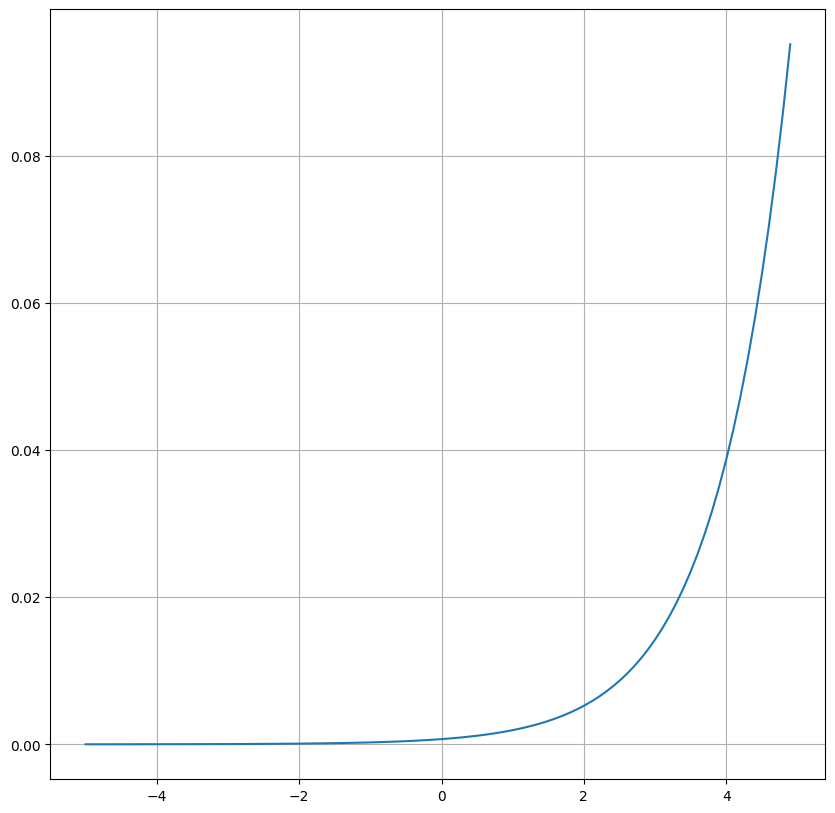

In [20]:
#
# Example of a plot of the activation function
#
t     = np.arange(-5,5,0.1)
alpha = 0. #np.arange(-50,50,1)
plt.figure(figsize=(10,10))
plt.plot(t,softmax(t,alpha))
plt.grid(True)
plt.show()

## Definition of a simple neural network

We use a one-layer fully-connected neural network with the <a href="https://en.wikipedia.org/wiki/Softmax_function">softmax</a> activation function.


In [21]:
def NN(x,W):
    """
    # One-layer fully connected neural network
    # x: image, i.e. 784x1 vector (28x28)
    # W: weight matrices of shape 10x784   
    """
    y = W@x
    alpha = -np.max(y)
    
    
    return softmax(y, alpha)

## Definition of the loss function

The loss function is the <a href="https://en.wikipedia.org/wiki/Cross_entropy">cross-entropy</a> defined by 

$$J(W)=-\sum_{i=1}^N p_i \log(q_i(W)),$$ where $N$ is the number of classes, $(p_i)_{i=1:N}$ are the probabilities of  a data from the training set to belong to a class (0 or 1 because the labels are known), and $(q_i(W))_{i=1:N}$ are the predicted probabilities from the model

$$\forall i=1:N, \quad q_i(W)=[\sigma_{\alpha}(Wx)]_i.$$

In [22]:
#
# Loss function = Cross-entropy
#
def cross_entropy(pred,target,x):
    """
    pred:   predicted probabilities (q(W))
    target: probabilities (p)
    x:      image 
    """ 
    #
    # TO DO: return ce (cross_entropy)
    #
    ce = -np.sum(target*np.log(pred))
    #
    # gradient of the cross-entropy
    s    =  pred
    u    =  np.ones((s.shape[0],1))
    g    = (-u.T.dot(target)*(s.dot(x.T))+target*x.T)
    grad = -g.reshape(x.shape[0]*target.shape[0],1)
    
    return ce,grad
#
# Main function 
#
def f(W,x,target):
    """
    W:      weights
    target: probabilities (p)
    x:      image
    """
    #
    # TO DO: return ce, grad, pred (cross_entropy, gradient, predicted probabilities)
    #
    pred = NN(x, W)
    ce, grad = cross_entropy(pred, target, x)
    
    return ce,grad,pred

In [23]:
#
# Test information on the gradient with calls of f
#

# Define weight matrices
w      = np.random.rand(10,Xtrain.shape[1])
eps    = 1e-8
d      = np.random.rand(10,Xtrain.shape[1])
Wtilde = w+eps*d

# Retrieve the information on the gradients
res    = (f(Wtilde,Xtrain[0],targets_train[0])[0]-f(w,Xtrain[0],targets_train[0])[0])/eps
print(res)

g      = f(w,Xtrain[0],targets_train[0])[1]
print(g.T.dot(d.reshape(7840,1)))

2.9312394289604526
[[2.93123982]]


## Generating batches 

In [24]:
#
# Function to create batches of samples to be used later in the training phase
#
def create_batches(x,bs):
    """
    x : set to be considered (array)
    bs: batch size (scalar)
    """
    batches = []
    ind     = np.arange(x.shape[0])
    random.shuffle(ind)
    nbatch  = ind.shape[0]//bs
    rest    = ind.shape[0]%bs
    
    for n in range(nbatch):
        batches += [ind[bs*n:bs*(n+1)]]
    
    # Put the remaining elements in a last batch
    if rest !=0:        
        batches += [ind[-rest:]]
        
    return batches

## Training of the neural network

In [25]:
history    = {}
eta        = 1e-1 # learning rate
momentum   = 0.   # momemtum factor
N_EPOCHS   = 10  
BatchSizes = [10000,1024,256, 100, 50] # try different batch sizes for the analysis

for bs in BatchSizes:
    #
    # Sensitivity to the batch size to be investigated in the analysis
    #
    print('batch size=',bs)
    
    history[bs]={'train loss':[],'train acc':[],'test loss':[0], 'test acc':[0]}
    
    # Initialization of the weights
    w = np.random.rand(10,Xtrain.shape[1])
    n_images = Xtrain.shape[0]
    for n in range(N_EPOCHS):
        # Minimization of the loss function
        
        Batches=create_batches(Xtrain,bs)
        
        losst = 0
        acct = 0
        for batch in Batches:
            # Loop on the batches
            acc = 0
            loss = 0
            sumgrad = 0
            for ind in batch :
                target = targets_train[ind]
                X = Xtrain[ind]
                ce, grad, pred = f(w, X, target)
                loss+=ce
                sumgrad += grad
                if np.argmax(pred) == np.argmax(target) : acc+=1  
            grad = sumgrad/len(batch)
            #print(np.linalg.norm(grad))
            w = w - eta*(grad).reshape(np.shape(w))
            history[bs]['train acc'].append(acc/len(batch))
            history[bs]['train loss'].append(loss/len(batch))
        
        # Test accuracy at the end of each epoch  
        #
        # TO DO
        #
        
        n_test = Xtest.shape[0]
        for i in range(n_test):
            target = targets_test[i]
            x = Xtest[i]
            ce, grad, pred = f(w, x, target)
            losst+=ce
            if np.argmax(pred) == np.argmax(target) : acct+=1
        history[bs]['test acc'].append(acct/n_test)
        history[bs]['test loss'].append(losst/n_test)
        
        
        
        print('Epoch number :', n+1,'test accuracy:',history[bs]['test acc'][n+1],'test loss',history[bs]['test loss'][n+1])
        

    print('\n')            

batch size= 10000
Epoch number : 1 test accuracy: 0.1707 test loss 2.9759478590305393
Epoch number : 2 test accuracy: 0.2857 test loss 2.4160069920142355
Epoch number : 3 test accuracy: 0.3679 test loss 2.0387472088622287
Epoch number : 4 test accuracy: 0.4398 test loss 1.7591233774377935
Epoch number : 5 test accuracy: 0.5001 test loss 1.5492922909067988
Epoch number : 6 test accuracy: 0.5479 test loss 1.3896834457907492
Epoch number : 7 test accuracy: 0.5851 test loss 1.2662777487786923
Epoch number : 8 test accuracy: 0.6219 test loss 1.1687850285518617
Epoch number : 9 test accuracy: 0.6476 test loss 1.0902782604532724
Epoch number : 10 test accuracy: 0.6713 test loss 1.0261335833592595


batch size= 1024
Epoch number : 1 test accuracy: 0.6325 test loss 1.1408476373541525
Epoch number : 2 test accuracy: 0.7476 test loss 0.789644288718016
Epoch number : 3 test accuracy: 0.7945 test loss 0.6565567645626452
Epoch number : 4 test accuracy: 0.8199 test loss 0.5860387937538344
Epoch numbe

## Plots of the evolution of the loss function

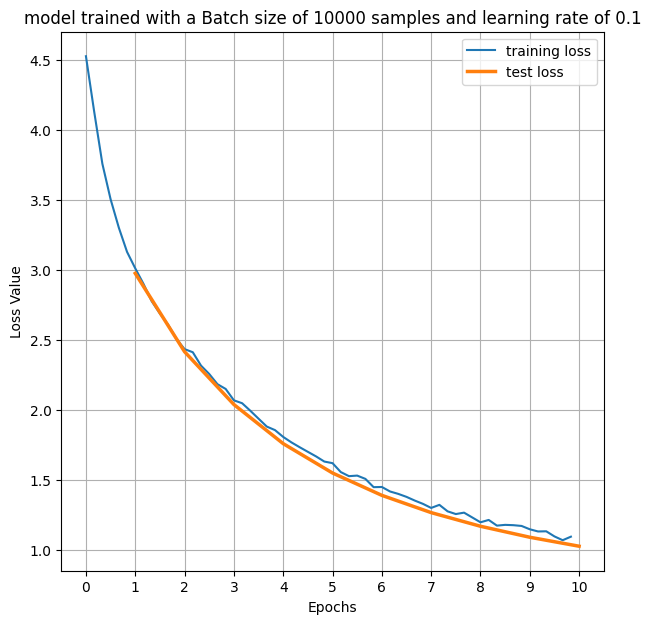

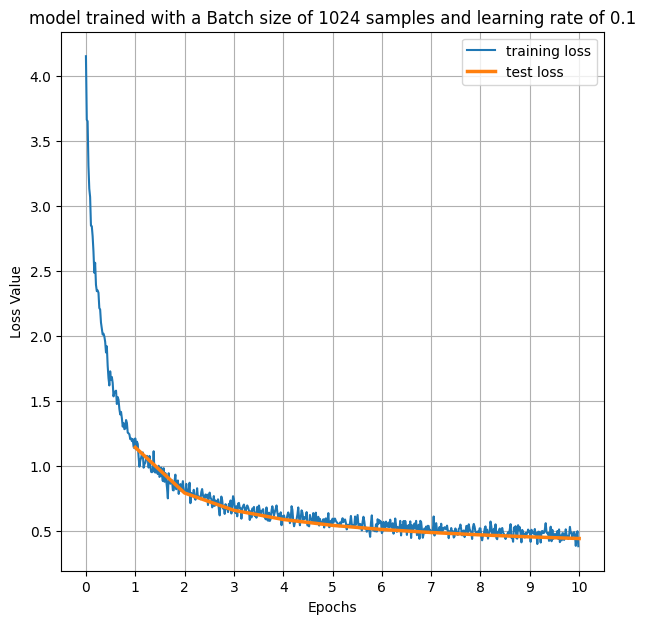

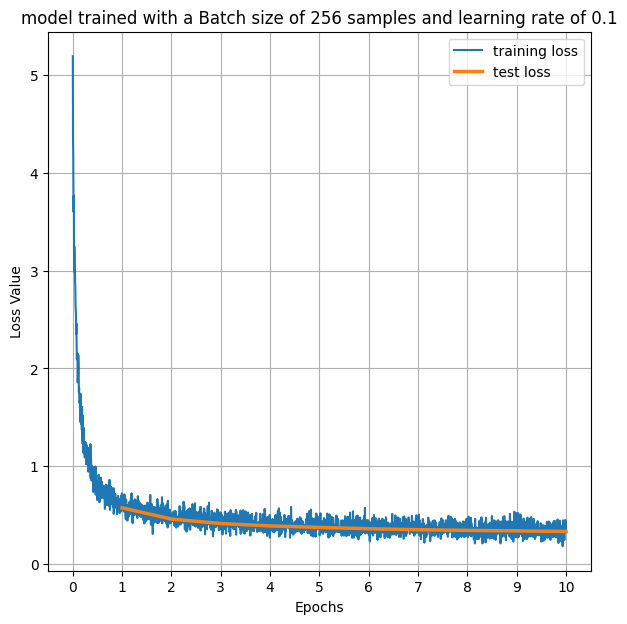

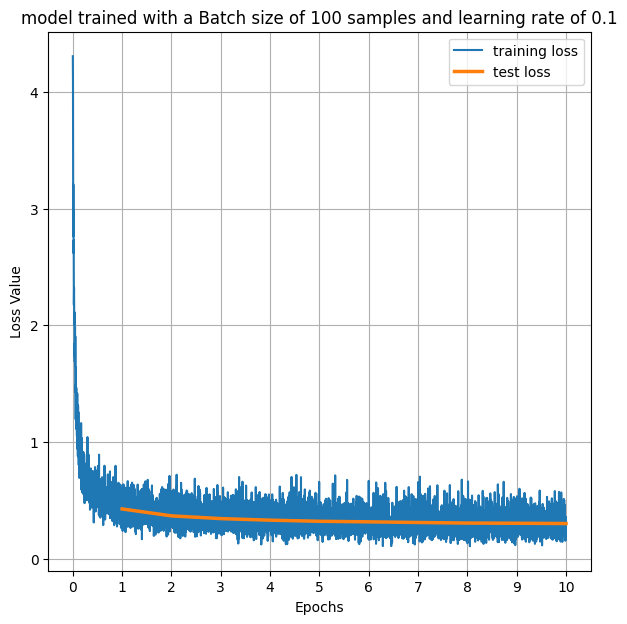

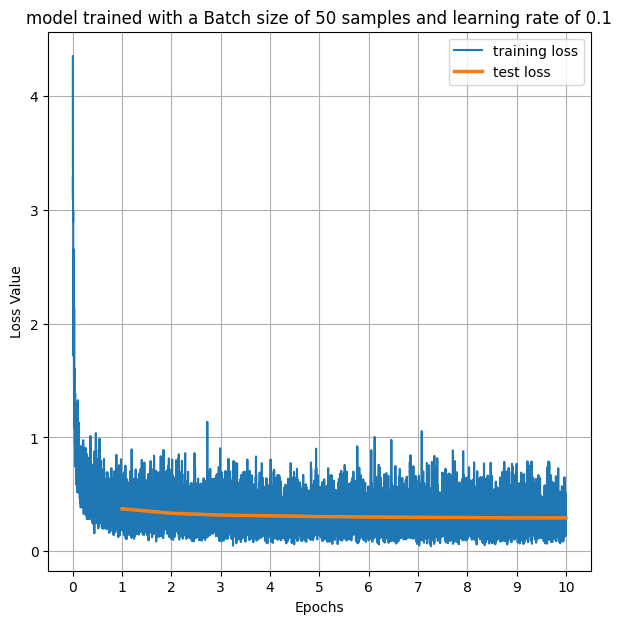

In [26]:
for bs in BatchSizes:
       
    n_batch = Xtrain.shape[0]//bs     
    if Xtrain.shape[0]%bs!=0:
        n_batch+=1
        
    E  = [n_batch*n for n in np.arange(N_EPOCHS+1)]
    Ep = [str(n) for n in np.arange(N_EPOCHS+1)]
    
    plt.figure(figsize=(7,7))
    plt.plot(history[bs]['train loss'],label = 'training loss')
    plt.plot(E[1:],history[bs]['test loss'][1:],linewidth=2.5,label = 'test loss')
    plt.xticks(E,Ep)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    #plt.ylim([0,np.max(history[bs]['test loss'])+2])
    plt.grid(True)
    plt.legend()
    plt.title(f'model trained with a Batch size of {bs} samples and learning rate of {eta}')
    plt.show()

## Plots of the evolution of the accuracy

10000
6


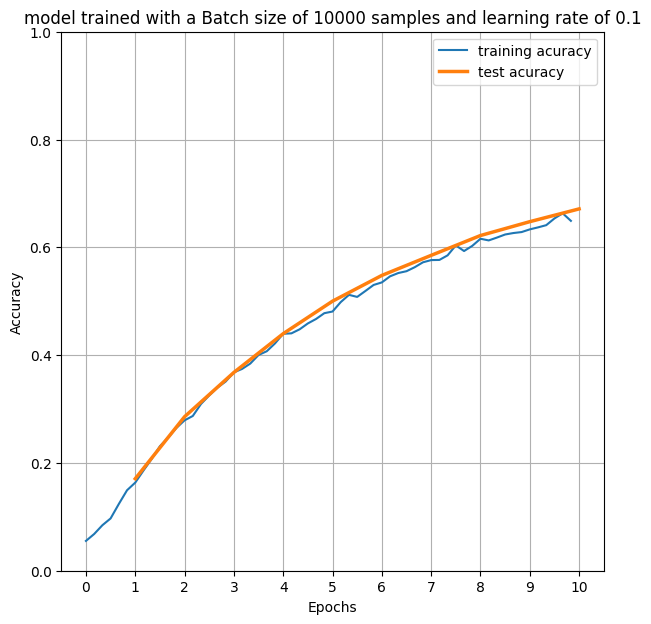

1024
59


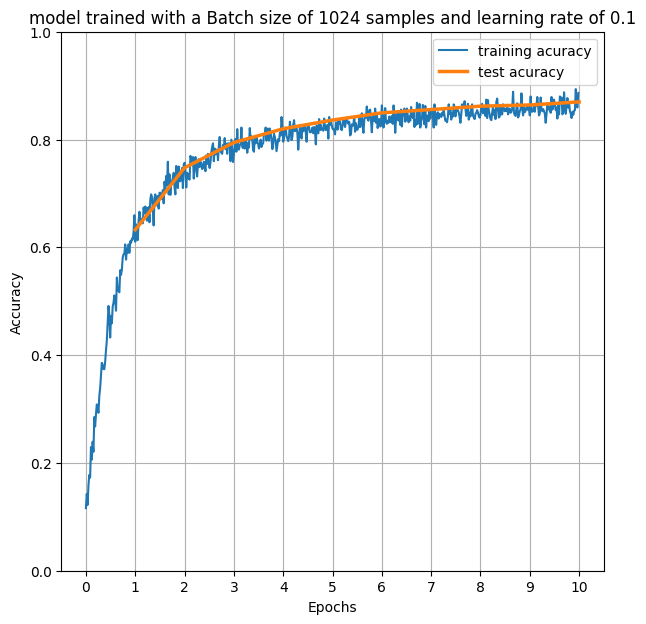

256
235


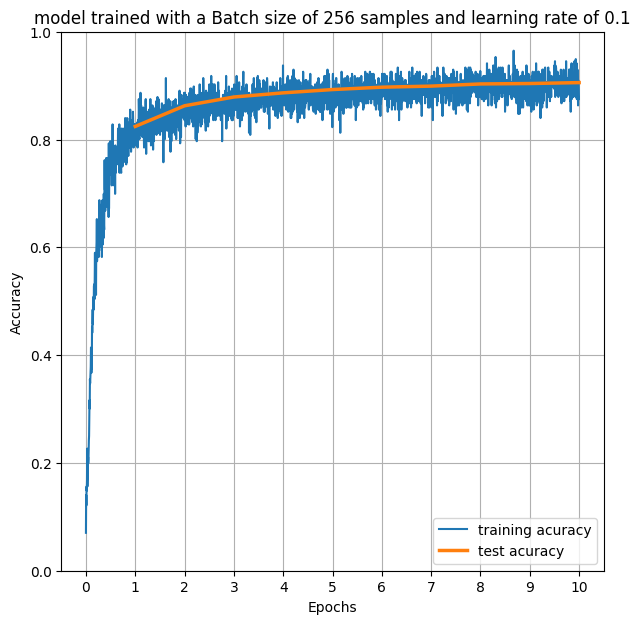

100
600


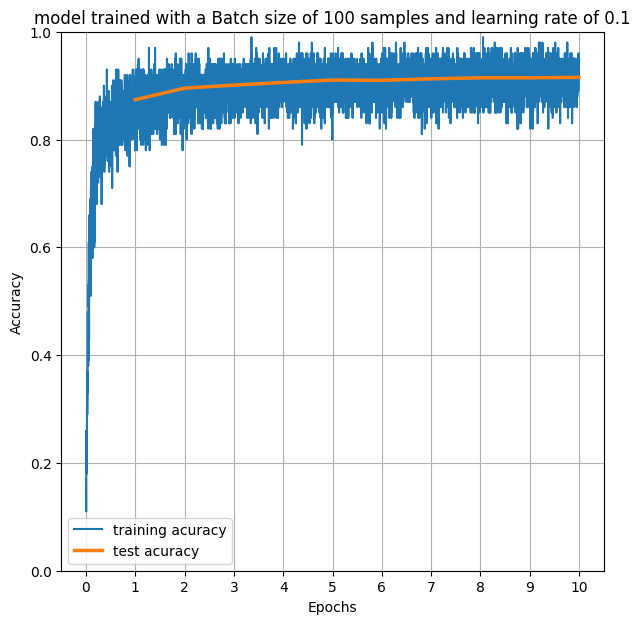

50
1200


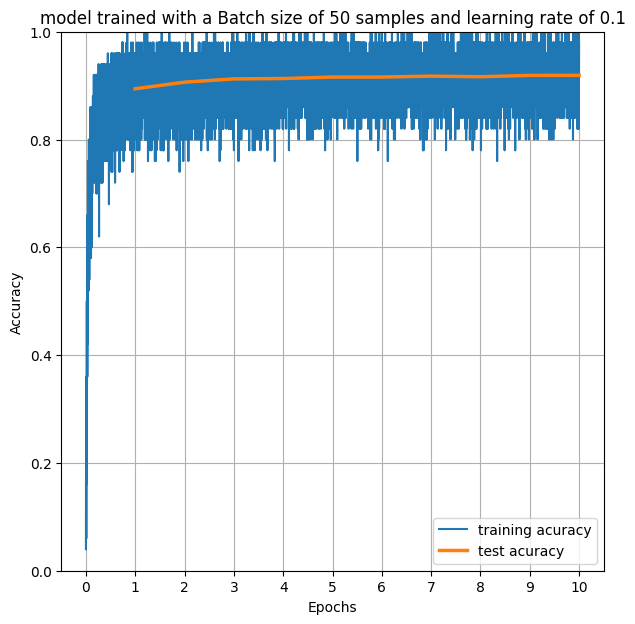

In [27]:
for bs in BatchSizes:
    print(bs)   
    n_batch = Xtrain.shape[0]//bs     
    if Xtrain.shape[0]%bs!=0:
        n_batch+=1
        
    print(n_batch)
    E=[n_batch*n for n in np.arange(N_EPOCHS+1)]
    Ep = [str(n) for n in np.arange(N_EPOCHS+1)]
    
    plt.figure(figsize=(7,7))
    plt.plot(history[bs]['train acc'] ,label  = 'training acuracy')
    plt.plot(E[1:],history[bs]['test acc'][1:],linewidth=2.5,label = 'test acuracy')
    plt.xticks(E,Ep)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.title(f'model trained with a Batch size of {bs} samples and learning rate of {eta}')
    plt.ylim([0,1])
    plt.legend()
    
    plt.show()

## Analysis of the results

Please provide your comments on the sensitivity of the results to the parameters involved in the learning process (batch size, learning rate, momentum).

### Your comments:

The bigger the size of the batch, the more accurate the grad is but the less you modify W.
When you decrease the size of the batch, you increase the number of time you modify W en the more accurate the neural network becomes. However, when the size of the batch becomes too low, you get overfitting and the accuracy of the neural network starts to swing.

The same happens with eta, if it's too low, the training is too slow but if it's too big, W evolves too much each times and the accuracy starts to swing.